In [1]:
import numpy as np 
import pandas as pd 


In [5]:
df = pd.read_csv("eco_counter_fahrradzaehler.csv")
df.head()

,timestamp,iso_timestamp,zählstand,stand,standort,channel_name,channel_id,counter_site,counter_site_id,domain_name,domain_id,longitude,latitude,timezone,interval,counter_serial
0,2025-06-16T00:00:00+0000,2025-06-16T00:00:00+0200,8,0,Stadt Tübingen,Richtung Altstadt,101003358,Fuß- & Radtunnel Südportal - Derendinger Allee,100003358,Stadt Tübingen,667,9.04806,48.518,(UTC+01:00) Europe/Paris;DST,15,YAH24052174
1,2025-06-16T01:00:00+0000,2025-06-16T01:00:00+0200,5,0,Stadt Tübingen,Richtung Altstadt,101003358,Fuß- & Radtunnel Südportal - Derendinger Allee,100003358,Stadt Tübingen,667,9.04806,48.518,(UTC+01:00) Europe/Paris;DST,15,YAH24052174
2,2025-06-16T02:00:00+0000,2025-06-16T02:00:00+0200,2,0,Stadt Tübingen,Richtung Altstadt,101003358,Fuß- & Radtunnel Südportal - Derendinger Allee,100003358,Stadt Tübingen,667,9.04806,48.518,(UTC+01:00) Europe/Paris;DST,15,YAH24052174
3,2025-06-16T03:00:00+0000,2025-06-16T03:00:00+0200,0,0,Stadt Tübingen,Richtung Altstadt,101003358,Fuß- & Radtunnel Südportal - Derendinger Allee,100003358,Stadt Tübingen,667,9.04806,48.518,(UTC+01:00) Europe/Paris;DST,15,YAH24052174
4,2025-06-16T04:00:00+0000,2025-06-16T04:00:00+0200,5,0,Stadt Tübingen,Richtung Altstadt,101003358,Fuß- & Radtunnel Südportal - Derendinger Allee,100003358,Stadt Tübingen,667,9.04806,48.518,(UTC+01:00) Europe/Paris;DST,15,YAH24052174


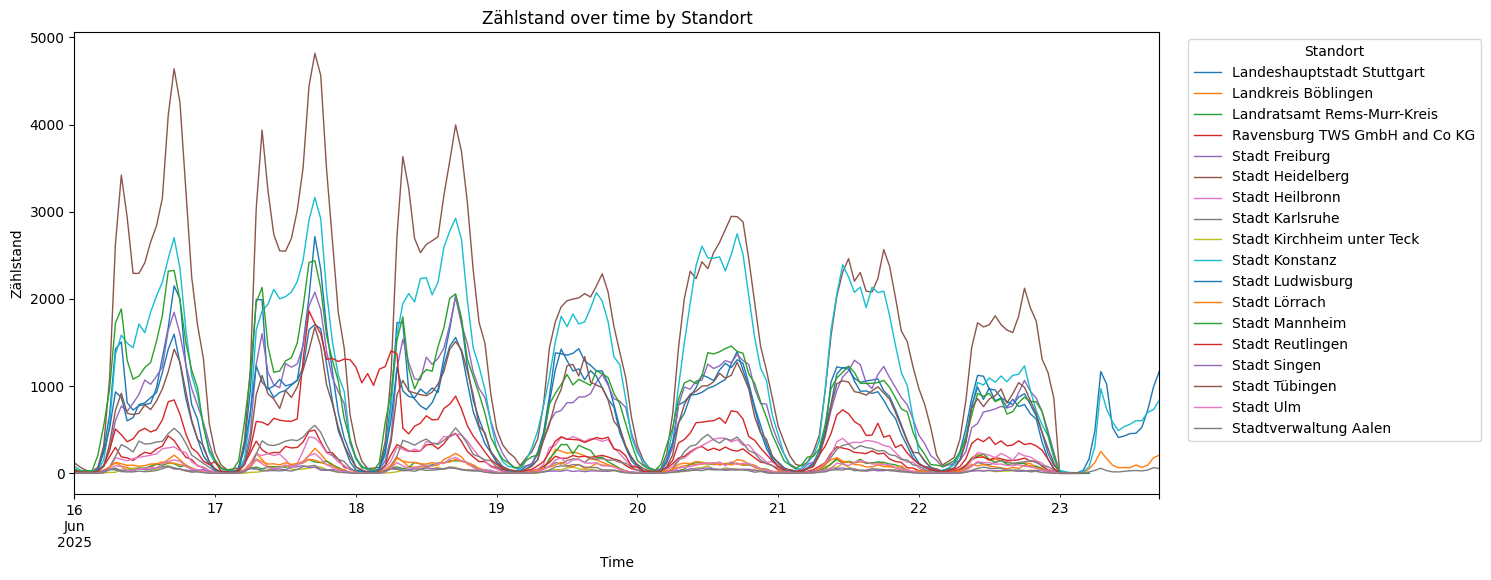

In [4]:
df = pd.read_csv("eco_counter_fahrradzaehler.csv")
df.head()

# Parse time and sort by city/location
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values(["standort", "timestamp"])

# One line per standort over time (sum in case of duplicate timestamp+standort rows)
plot_df = df.pivot_table(
    index="timestamp",
    columns="standort",
    values="zählstand",
    aggfunc="sum"
)

ax = plot_df.plot(figsize=(14, 6), linewidth=1)
ax.set_title("Zählstand over time by Standort")
ax.set_xlabel("Time")
ax.set_ylabel("Zählstand")
ax.legend(title="Standort", bbox_to_anchor=(1.02, 1), loc="upper left")

In [6]:
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

monthly_df = (
    df.assign(timestamp_month=df["timestamp"].dt.to_period("M").dt.to_timestamp())
      .groupby(["timestamp_month", "standort", "counter_site"], as_index=False)["zählstand"]
      .sum()
      .sort_values(["timestamp_month", "standort", "counter_site"])
)

monthly_df.head()

C:\Users\jgasting\AppData\Local\Temp\ipykernel_43376\2642908536.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df.assign(timestamp_month=df["timestamp"].dt.to_period("M").dt.to_timestamp())


,timestamp_month,standort,counter_site,zählstand
0,2025-06-01,Landeshauptstadt Stuttgart,Am Kräherwald,3936
1,2025-06-01,Landeshauptstadt Stuttgart,Böblinger Straße,11376
2,2025-06-01,Landeshauptstadt Stuttgart,Inselstraße,11277
3,2025-06-01,Landeshauptstadt Stuttgart,Kirchheimer Straße,6804
4,2025-06-01,Landeshauptstadt Stuttgart,Kremmlerstraße,9095


In [8]:
# Keep only counter sites that are present in at least 80% of all timestamps
total_timestamps = df["timestamp"].nunique()

counter_site_availability = (
    df.groupby("counter_site")["timestamp"]
      .nunique()
      .div(total_timestamps)
)

valid_counter_sites = counter_site_availability[counter_site_availability >= 0.8].index

df_filtered = df[df["counter_site"].isin(valid_counter_sites)].copy()

print(f"Kept {len(valid_counter_sites)} counter_sites out of {counter_site_availability.shape[0]}")
df_filtered.head()

Kept 99 counter_sites out of 103


,timestamp,iso_timestamp,zählstand,stand,standort,channel_name,channel_id,counter_site,counter_site_id,domain_name,domain_id,longitude,latitude,timezone,interval,counter_serial
0,2025-06-16 00:00:00+00:00,2025-06-16T00:00:00+0200,8,0,Stadt Tübingen,Richtung Altstadt,101003358,Fuß- & Radtunnel Südportal - Derendinger Allee,100003358,Stadt Tübingen,667,9.04806,48.518,(UTC+01:00) Europe/Paris;DST,15,YAH24052174
1,2025-06-16 01:00:00+00:00,2025-06-16T01:00:00+0200,5,0,Stadt Tübingen,Richtung Altstadt,101003358,Fuß- & Radtunnel Südportal - Derendinger Allee,100003358,Stadt Tübingen,667,9.04806,48.518,(UTC+01:00) Europe/Paris;DST,15,YAH24052174
2,2025-06-16 02:00:00+00:00,2025-06-16T02:00:00+0200,2,0,Stadt Tübingen,Richtung Altstadt,101003358,Fuß- & Radtunnel Südportal - Derendinger Allee,100003358,Stadt Tübingen,667,9.04806,48.518,(UTC+01:00) Europe/Paris;DST,15,YAH24052174
3,2025-06-16 03:00:00+00:00,2025-06-16T03:00:00+0200,0,0,Stadt Tübingen,Richtung Altstadt,101003358,Fuß- & Radtunnel Südportal - Derendinger Allee,100003358,Stadt Tübingen,667,9.04806,48.518,(UTC+01:00) Europe/Paris;DST,15,YAH24052174
4,2025-06-16 04:00:00+00:00,2025-06-16T04:00:00+0200,5,0,Stadt Tübingen,Richtung Altstadt,101003358,Fuß- & Radtunnel Südportal - Derendinger Allee,100003358,Stadt Tübingen,667,9.04806,48.518,(UTC+01:00) Europe/Paris;DST,15,YAH24052174


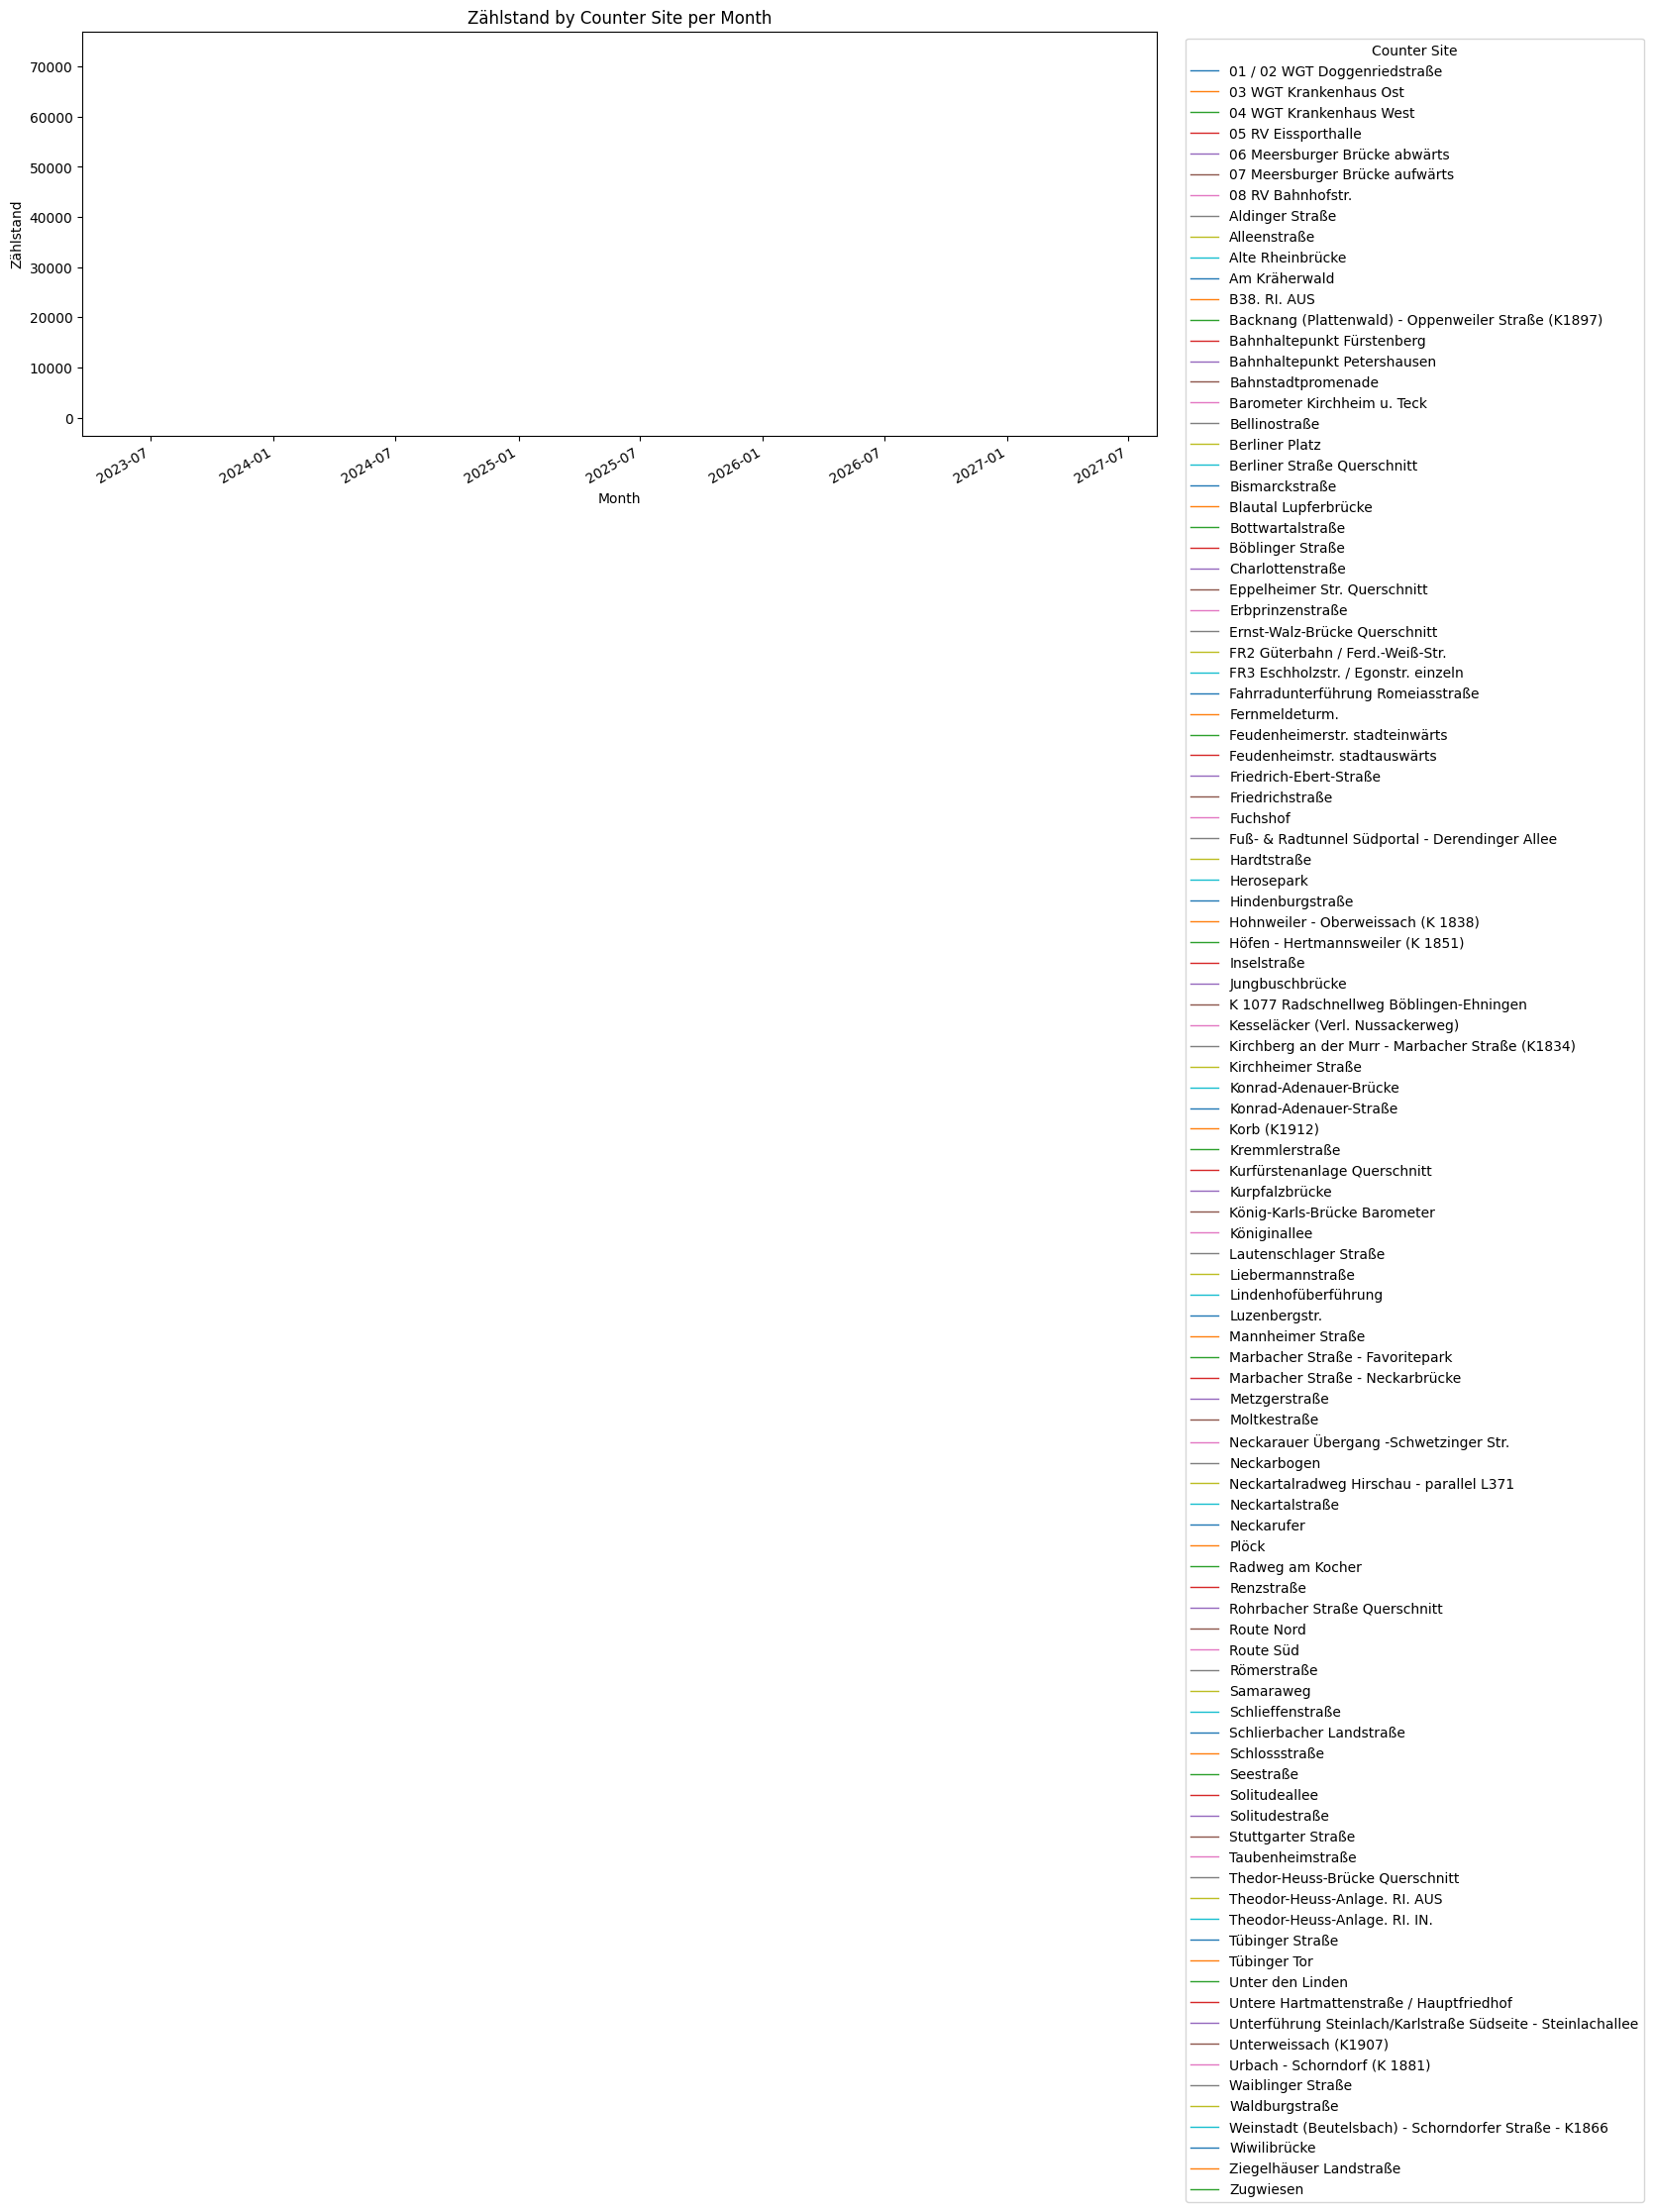

In [9]:
plot_counter_site = monthly_df.pivot_table(
    index="timestamp_month",
    columns="counter_site",
    values="zählstand",
    aggfunc="sum"
).sort_index()

ax = plot_counter_site.plot(figsize=(14, 6), linewidth=1)
ax.set_title("Zählstand by Counter Site per Month")
ax.set_xlabel("Month")
ax.set_ylabel("Zählstand")
ax.legend(title="Counter Site", bbox_to_anchor=(1.02, 1), loc="upper left")